# PALM LES PM2.5 Surrogate — Data EDA & Preprocessing
## London Camden 8 km · 10 m resolution · 1-hour averages

**Target** `y`: PALM hourly-mean PM2.5, lowest **12 levels (15–195 m)**, shape `(12, H, W)`.

**Input** `X`: **9 physical variables × {t, t−1} = 18 channels** (one hour of forcing
history), shape `(18, 12, H, W)`:

| block | ch (t) | ch (t−1) | Variable | Source | Preprocessing |
|-------|:---:|:---:|----------|--------|---------------|
| emission     | 0 | 1  | PM2.5 surface emission   | `_chemistry`        | log1p → z-score |
| u wind       | 2 | 10 | `ls_forcing_left_u`      | `_dynamic` (ERA5)   | z-score |
| v wind       | 3 | 11 | `ls_forcing_left_v`      | `_dynamic` (ERA5)   | z-score |
| pt           | 4 | 12 | `ls_forcing_left_pt`     | `_dynamic` (ERA5)   | z-score |
| qv           | 5 | 13 | `ls_forcing_left_qv`     | `_dynamic` (ERA5)   | z-score |
| boundary PM2.5 | 6 | 14 | `ls_forcing_left_PM25` | `_dynamic` (CAMS)   | log1p → z-score |
| surface pressure | 7 | 15 | `surface_forcing_surface_pressure` | `_dynamic` | z-score |
| hour_sin     | 8 | 16 | sin(2πh/24)              | timestamp           | none |
| hour_cos     | 9 | 17 | cos(2πh/24)              | timestamp           | none |

*Building height, terrain and land use define the domain and the building mask
(NaN = inside buildings); vertical height enters through the model's internal
per-level encoding, so they are **not** explicit input channels.*

## Part 0: Imports and Configuration

In [1]:
import os, glob, warnings
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import scipy.stats as sp_stats
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '../../src')
from dataloader import BASE_DIR, SIM_CONFIG, PALM_Z_IDX, N_Z, DYN_PROFILE_VARS

REF     = 'london_cm20190820-23'
REF_CFG = SIM_CONFIG[REF]
REF_INP = os.path.join(BASE_DIR, REF, 'INPUT')
REF_OUT = os.path.join(BASE_DIR, REF, 'OUTPUT')
PM25_SCALE = 1e9
colors_ep  = ['steelblue', 'darkorange', 'seagreen']
labels_ep  = [SIM_CONFIG[s]['label'] for s in SIM_CONFIG]

av_files = sorted(glob.glob(os.path.join(REF_OUT, '*_av_xy.*.nc')))
with nc.Dataset(av_files[0]) as ds:
    z_xy_all = np.array(ds.variables['zu_xy'][:])   # all 17 PALM levels (incl. z0~5m)

# z0 (~5m) is excluded (PALM_OUT_Z0=1) — 16 levels used
z_levels = z_xy_all[1:]   # (16,) heights in metres

print(f'All PALM levels ({len(z_xy_all)}): {z_xy_all.round(1)}')
print(f'z0 (excluded): {z_xy_all[0]:.1f} m')
print(f'Used 16 levels: {z_levels.round(1)}')

All PALM levels (17): [   5.    15.    25.    35.    45.    55.    75.    95.   115.   135.
  155.   175.   195.   295.   419.9  878.3 1783.2]
z0 (excluded): 5.0 m
Used 16 levels: [  15.    25.    35.    45.    55.    75.    95.   115.   135.   155.
  175.   195.   295.   419.9  878.3 1783.2]


## Study area

The domain is an **800 × 800 grid at 10 m** (8 × 8 km) over the **London Borough of Camden**,
central London. Panel (a) locates it within Greater London; panel (b) shows the Camden domain
on an OpenStreetMap basemap, with the two held-out **spatial-transfer tiles** marked
(tile 1 = interior block, tile 2 = central-London block).

![Study area](figs/study_area_combined.png)

*Basemaps © OpenStreetMap contributors (© CARTO for panel a). Grid coordinates in OSGB
(British National Grid) metres; panel (b) axes are in grid cells (0–800 → 0–8 km).*

---
## Part 1: EDA

### 1.1  Dataset Overview

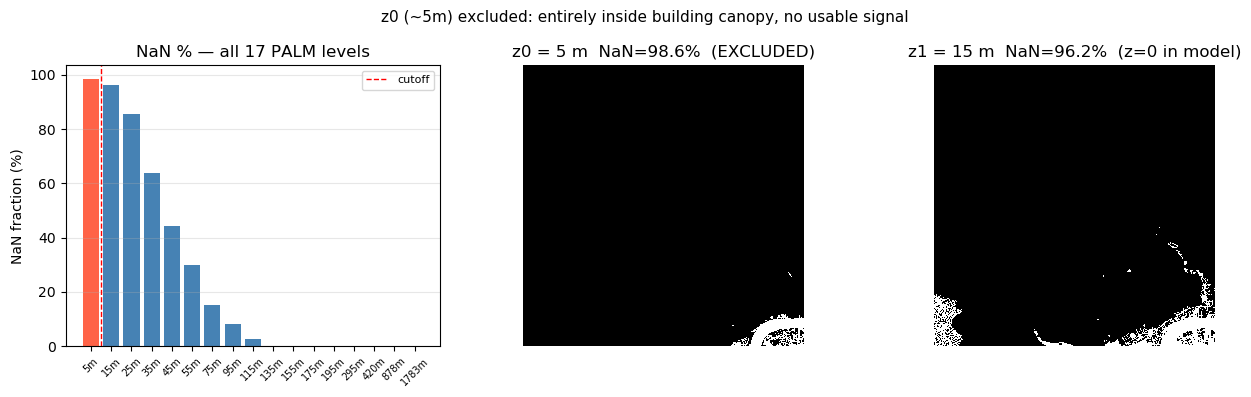

z0 (5m): 98.6
z1 (15m): 96.2


In [2]:
# Why z0 (~5m) is excluded: nearly 100% NaN (all below building height)
with nc.Dataset(av_files[0]) as ds:
    pm_t0 = np.array(ds.variables['kc_PM25_xy'][0].filled(np.nan))  # (17, 800, 800)

nan_all = [100 * np.isnan(pm_t0[i]).mean() for i in range(17)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].bar(range(17), nan_all, color=['tomato']+['steelblue']*16)
axes[0].set_xticks(range(17))
axes[0].set_xticklabels([f'{z_xy_all[i]:.0f}m' for i in range(17)], rotation=45, fontsize=7)
axes[0].set_ylabel('NaN fraction (%)'); axes[0].set_title('NaN % — all 17 PALM levels')
axes[0].axvline(0.5, color='red', ls='--', lw=1, label='cutoff')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].imshow(~np.isnan(pm_t0[0]), cmap='gray', origin='lower')
axes[1].set_title(f'z0 = {z_xy_all[0]:.0f} m  NaN={nan_all[0]:.1f}%  (EXCLUDED)'); axes[1].axis('off')

axes[2].imshow(~np.isnan(pm_t0[1]), cmap='gray', origin='lower')
axes[2].set_title(f'z1 = {z_xy_all[1]:.0f} m  NaN={nan_all[1]:.1f}%  (z=0 in model)'); axes[2].axis('off')

plt.suptitle('z0 (~5m) excluded: entirely inside building canopy, no usable signal', fontsize=11)
plt.tight_layout(rect=[0,0,1,0.93]); plt.show()
print(f'z0 ({z_xy_all[0]:.0f}m): {nan_all[0]:.1f}')
print(f'z1 ({z_xy_all[1]:.0f}m): {nan_all[1]:.1f}')

In [3]:
print(f"{'Simulation':<30} {'Hours':>7} {'Train':>7} {'Test':>6}")
print('-'*55)
for sim, cfg in SIM_CONFIG.items():
    print(f"{sim:<30} {cfg['sim_hours']:>7}")

Simulation                       Hours   Train   Test
-------------------------------------------------------
london_cm20190720-23                96
london_cm20190820-23                96
london_cm20190904-07               144


### 1.2  Domain morphology — buildings & terrain

Static geometry from the `_static` driver. These **define the domain and the building
mask** (and terrain-following heights) but are **not** input channels of the surrogate;
the model receives vertical position through an internal per-level height encoding.
Shown here for context and for the paper's domain figures.

In [4]:
static_path = os.path.join(REF_INP, REF_CFG['static_file'])
with nc.Dataset(static_path) as ds:
    st  = np.array(ds.variables['street_type'][:],  dtype=np.float32)
    fv  = getattr(ds.variables['street_type'], '_FillValue', None)
    if fv is not None: st[st == float(fv)] = 0.0
    b2d = np.array(ds.variables['buildings_2d'][:], dtype=np.float32)
    b2d[b2d == float(ds.variables['buildings_2d']._FillValue)] = 0.0
    zt  = np.array(ds.variables['zt'][:],           dtype=np.float32)
    fv  = getattr(ds.variables['zt'], '_FillValue', None)
    if fv is not None: zt[zt == float(fv)] = 0.0

print(f'street_type : unique={sorted(np.unique(st).astype(int))}  non-zero={100*(st>0).mean():.1f}%')
print(f'buildings_2d: min={b2d.min():.1f}  max={b2d.max():.1f}  mean={b2d.mean():.2f}  zero={100*(b2d==0).mean():.1f}%')
print(f'zt          : min={zt.min():.1f}  max={zt.max():.1f}  mean={zt.mean():.2f}')

street_type : unique=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  non-zero=26.0%
buildings_2d: min=0.0  max=140.0  mean=4.18  zero=74.3%
zt          : min=0.0  max=135.8  mean=43.47


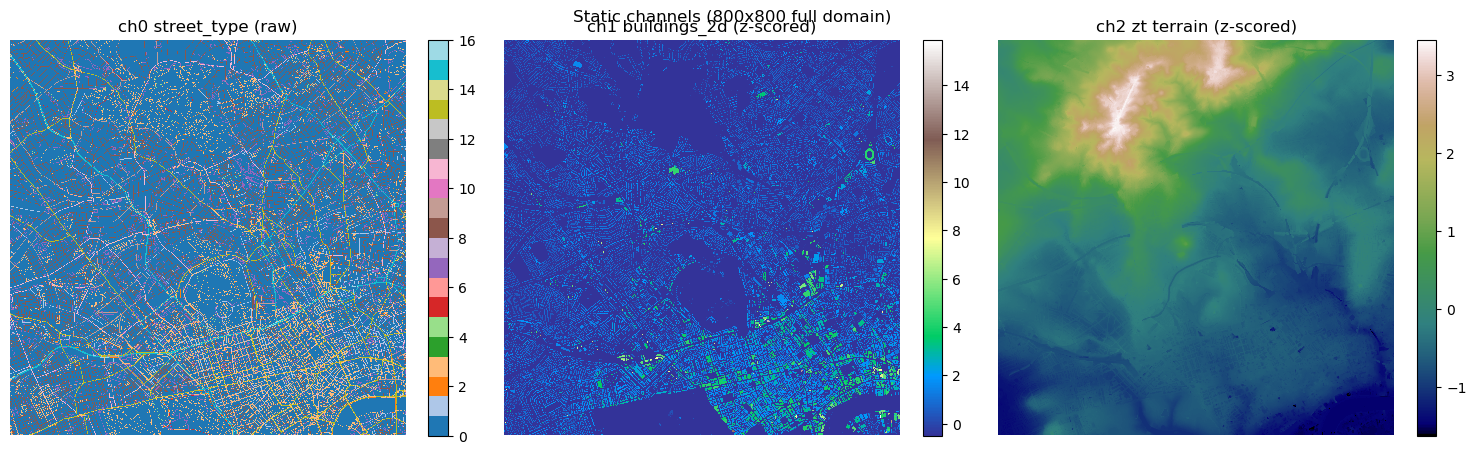

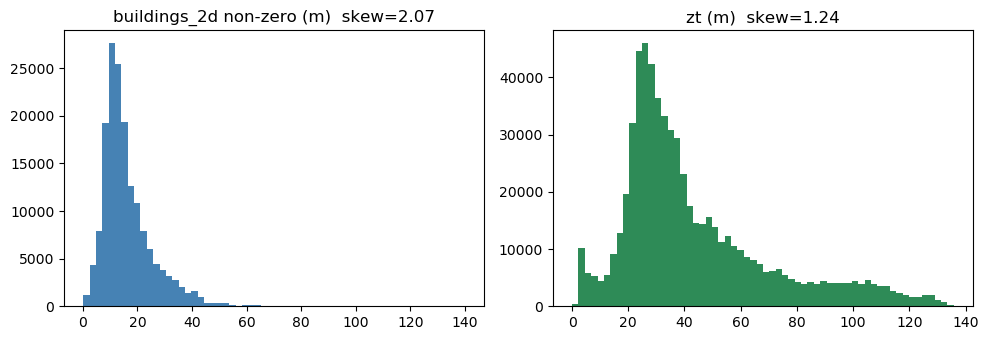

In [5]:
b2d_zs = (b2d - b2d.mean()) / (b2d.std() + 1e-8)
zt_zs  = (zt  - zt.mean())  / (zt.std()  + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].imshow(st,     cmap='tab20',     origin='lower')
im1 = axes[1].imshow(b2d_zs, cmap='terrain',   origin='lower')
im2 = axes[2].imshow(zt_zs,  cmap='gist_earth',origin='lower')
for ax, im, lbl in zip(axes, [im0,im1,im2], ['ch0 street_type (raw)', 'ch1 buildings_2d (z-scored)', 'ch2 zt terrain (z-scored)']):
    plt.colorbar(im, ax=ax, fraction=0.046); ax.set_title(lbl); ax.axis('off')
plt.suptitle('Static channels (800x800 full domain)', fontsize=12)
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(b2d[b2d>0].ravel(), bins=60, color='steelblue')
axes[0].set_title(f'buildings_2d non-zero (m)  skew={sp_stats.skew(b2d[b2d>0]):.2f}')
axes[1].hist(zt.ravel(), bins=60, color='seagreen')
axes[1].set_title(f'zt (m)  skew={sp_stats.skew(zt.ravel()):.2f}')
plt.tight_layout(); plt.show()

*buildings_2d / zt characterise the urban canopy and terrain. They are visualised
above (and geo-referenced in 1.2b) but are not fed to the network as channels — height
information is injected internally per level.*

### 1.2b  Geo-referenced domain maps (paper figures)

Standalone, title-free maps of building height and terrain elevation on real-world **OSGB** axes
(Easting/Northing, m). Origin (SW corner) = E523850, N180050; domain 8×8 km at 10 m.
Saved to `figs/building_height.png` and `figs/terrain_elevation.png`.

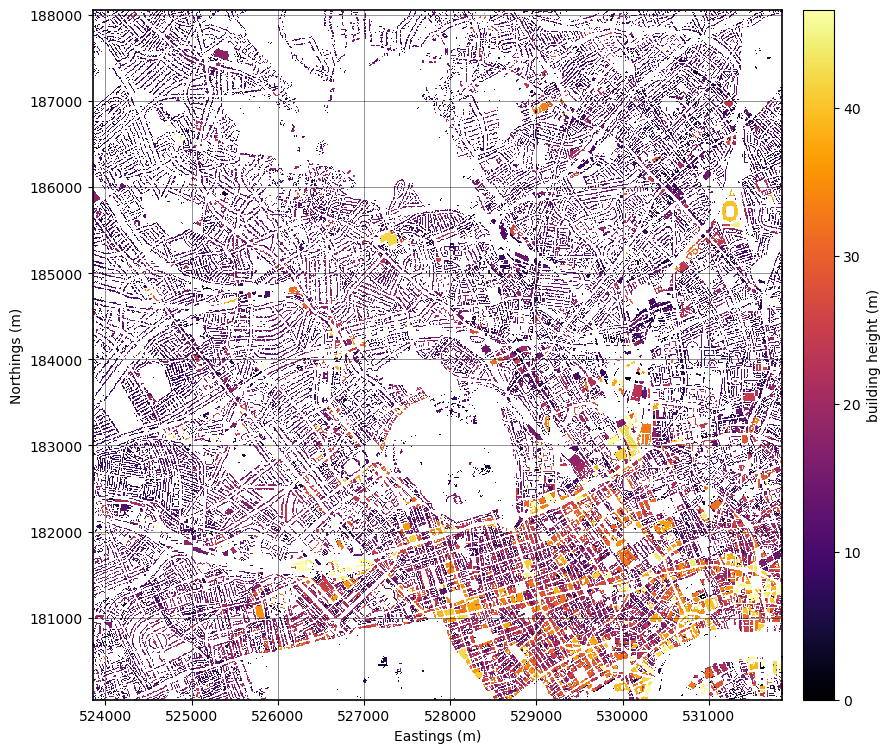

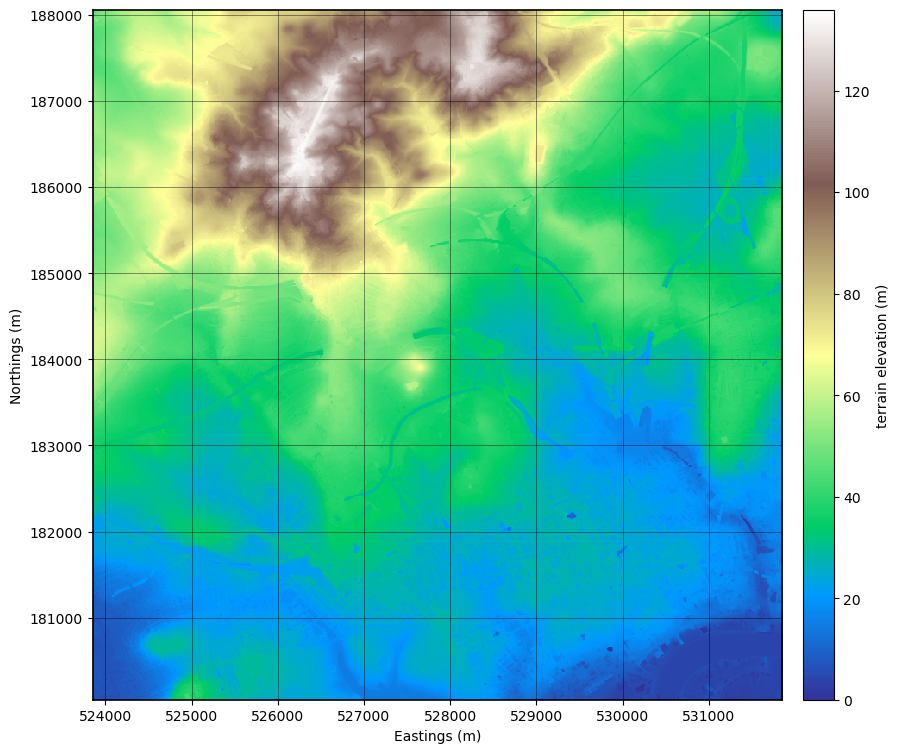

In [6]:
# Geo-referenced domain maps (paper figures) — building height & terrain, OSGB coords
# Reuses b2d, zt, static_path from cell 1.2. Same code path as draw_study_area_map.py
# (subplots 8x8 + tight_layout), so the MAP AXIS is pixel-identical (689x689) to the
# study-area panels; the inset colorbar hangs OUTSIDE and only widens the canvas to the
# right (map size unchanged). Coordinate style: Eastings/Northings, 1 km grid.
import matplotlib.ticker as mticker
FIGDIR = 'figs'; os.makedirs(FIGDIR, exist_ok=True)

with nc.Dataset(static_path) as ds:              # OSGB origin (SW corner) for real-world axes
    E0, N0 = float(ds.origin_x), float(ds.origin_y)
ny, nx = b2d.shape
ext   = [E0, E0 + nx * 10, N0, N0 + ny * 10]     # metres (10 m grid)
b2d_m = np.where(b2d > 0, b2d, np.nan)           # NaN = non-building (clean background)

def _domain_map(field, cmap, label, vmax, fname):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(field, cmap=cmap, vmin=0, vmax=vmax, origin='lower', extent=ext, zorder=1)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_aspect('equal')
    ax.ticklabel_format(style='plain')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1000))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1000))
    ax.grid(True, which='major', color='black', linewidth=0.5, alpha=0.6)
    ax.set_xlabel('Eastings (m)'); ax.set_ylabel('Northings (m)')
    for sp in ax.spines.values(): sp.set_edgecolor('black'); sp.set_linewidth(1.2)
    fig.tight_layout()
    cax = ax.inset_axes([1.03, 0.0, 0.045, 1.0])          # colorbar outside -> map keeps full size
    fig.colorbar(im, cax=cax).set_label(label)
    fig.savefig(f'{FIGDIR}/{fname}', dpi=200, bbox_inches='tight'); plt.show()

_domain_map(b2d_m, 'inferno', 'building height (m)',   np.nanpercentile(b2d_m, 99), 'building_height.png')
_domain_map(zt,    'terrain', 'terrain elevation (m)', np.nanmax(zt),               'terrain_elevation.png')

### 1.2c  3D city geometry

Building heights (`buildings_2d`) standing on the terrain relief (`zt`), on a coarse
50×50 grid (16× down-sampled from 800×800). Shows the dense urban canopy of Camden and
the Hampstead Heath high ground to the north — the surface morphology the LES resolves
and that the domain/building mask encode.

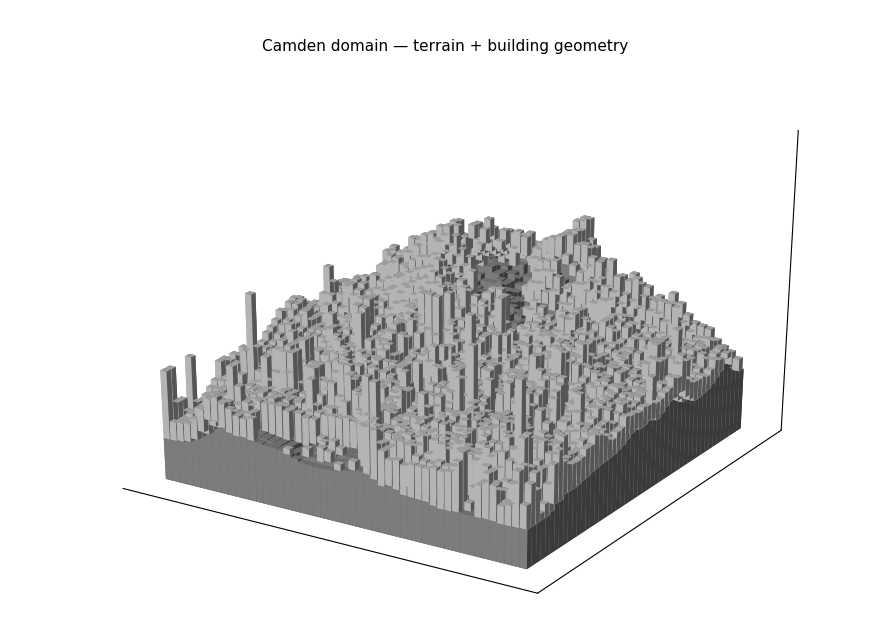

In [7]:
from mpl_toolkits.mplot3d import Axes3D
F=16; _ny,_nx=b2d.shape
def _pool(a,fn): return fn(a.reshape(_ny//F,F,_nx//F,F),axis=(1,3))
B3=_pool(b2d,np.max); T3=_pool(zt,np.mean); T3=T3-T3.min()   # terrain relief (0 baseline)
n=B3.shape[0]
_xs,_ys=np.meshgrid(np.arange(n),np.arange(n)); _xs=_xs.ravel(); _ys=_ys.ravel()
Tf=T3.ravel(); Bf=B3.ravel(); BASE=-40
fig=plt.figure(figsize=(9,6.5)); ax=fig.add_subplot(111,projection='3d')
ax.bar3d(_xs,_ys,BASE,1.0,1.0,Tf-BASE,color='0.55',shade=True,zsort='max')      # solid terrain base
m=Bf>5
ax.bar3d(_xs[m],_ys[m],Tf[m],0.88,0.88,Bf[m],color='0.80',shade=True,zsort='max')  # buildings
ax.set_zlim(BASE,(Tf+Bf).max()*1.7); ax.view_init(elev=30,azim=-58)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
for _a in (ax.xaxis,ax.yaxis,ax.zaxis): _a.pane.set_visible(False)
ax.grid(False)
ax.set_title('Camden domain — terrain + building geometry',fontsize=11)
plt.tight_layout(); plt.show()

### 1.3  PM2.5 Surface Emission (input ch 0 / 1 = t / t−1)

zero fraction: 0.5%


non-zero: min=14.81  max=24866.14  mean=484.89  skew=5.23


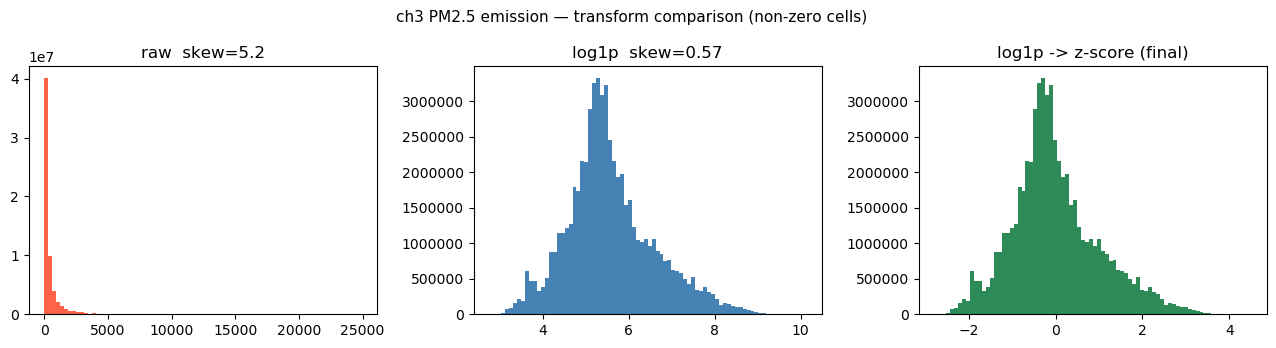

In [8]:
# Load Aug emission
em_path = os.path.join(REF_INP, REF_CFG['chem_file'])
with nc.Dataset(em_path) as ds:
    t_hrs = np.array(ds.variables['time'][:])
    mask  = t_hrs <= REF_CFG['sim_hours']
    names = [''.join([c.decode() if isinstance(c, bytes) else '' for c in row
                      if not np.ma.is_masked(c)]).strip()
             for row in ds.variables['emission_name'][:]]
    ev = np.ma.filled(ds.variables['emission_values'][mask], 0.0).astype(np.float32)
em_pm25 = ev[:, 0, :, :, names.index('PM25')] * PM25_SCALE  # (T, Y, X)

em_flat = em_pm25.ravel()
em_nz   = em_flat[em_flat > 0]
print(f'zero fraction: {100*(em_flat==0).mean():.1f}%')
print(f'non-zero: min={em_nz.min():.2f}  max={em_nz.max():.2f}  mean={em_nz.mean():.2f}  skew={sp_stats.skew(em_nz):.2f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(em_nz, bins=80, color='tomato');  axes[0].set_title(f'raw  skew={sp_stats.skew(em_nz):.1f}')
axes[1].hist(np.log1p(em_nz), bins=80, color='steelblue'); axes[1].set_title(f'log1p  skew={sp_stats.skew(np.log1p(em_nz)):.2f}')
vl = np.log1p(em_nz); vz = (vl - vl.mean()) / vl.std()
axes[2].hist(vz, bins=80, color='seagreen'); axes[2].set_title('log1p -> z-score (final)')
plt.suptitle('ch3 PM2.5 emission — transform comparison (non-zero cells)', fontsize=11)
plt.tight_layout(rect=[0,0,1,0.92]); plt.show()

### 1.4  ERA5 / CAMS Boundary Profiles (u, v, pt, qv, PM2.5 — ch 2–6 & 10–14)

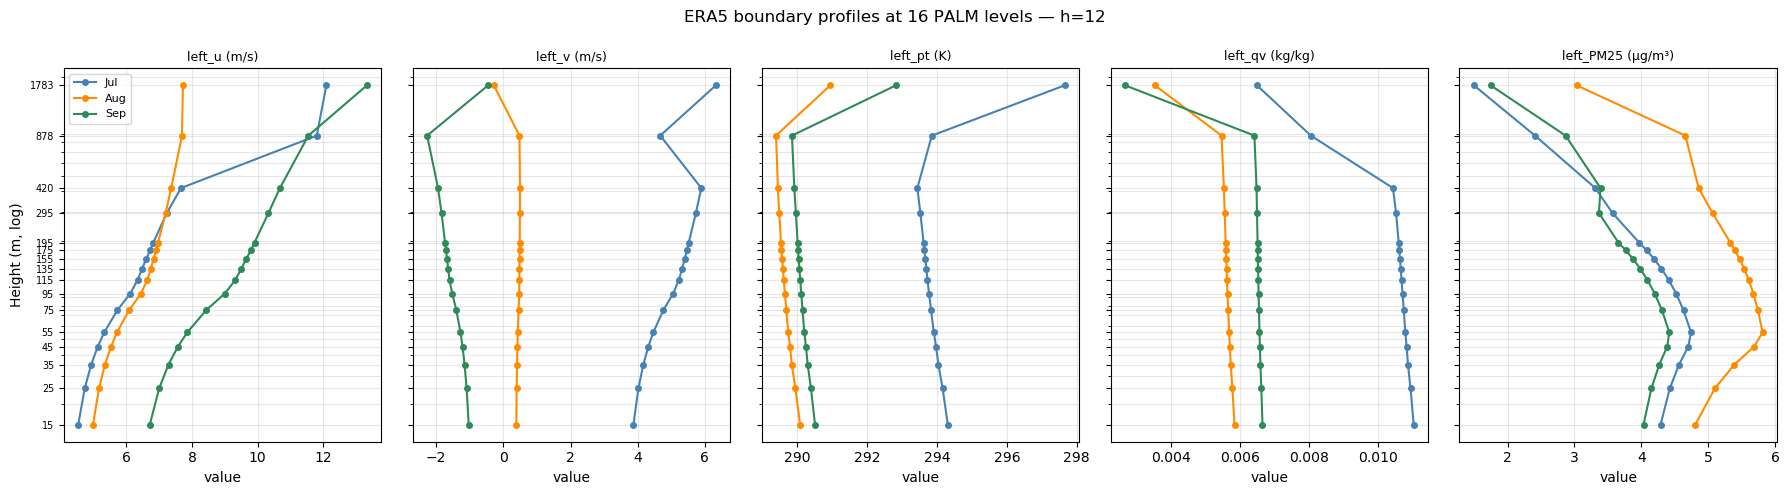

In [9]:
dyn_path = os.path.join(REF_INP, REF_CFG['dyn_file'])
with nc.Dataset(dyn_path) as ds:
    t_h  = np.array(ds.variables['time'][:]) / 3600
    mk   = t_h <= REF_CFG['sim_hours']
    profiles_aug = {v: np.array(ds.variables[v][mk][:, PALM_Z_IDX]) for v in DYN_PROFILE_VARS}
    z_dyn = np.array(ds.variables['z'][PALM_Z_IDX])

var_labels = ['left_u (m/s)', 'left_v (m/s)', 'left_pt (K)', 'left_qv (kg/kg)', 'left_PM25 (μg/m³)']

# Vertical profiles at h=12
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
for ax, var, lbl in zip(axes, DYN_PROFILE_VARS, var_labels):
    for sim, col, ep_lbl in zip(SIM_CONFIG, colors_ep, labels_ep):
        p = os.path.join(BASE_DIR, sim, 'INPUT', SIM_CONFIG[sim]['dyn_file'])
        with nc.Dataset(p) as ds:
            th = np.array(ds.variables['time'][:]) / 3600
            vd = np.array(ds.variables[var][th <= SIM_CONFIG[sim]['sim_hours']][:, PALM_Z_IDX])
        prof = vd[12] * (PM25_SCALE if var == 'ls_forcing_left_PM25' else 1.0)
        ax.plot(prof, z_dyn, 'o-', color=col, label=ep_lbl, markersize=4)
    ax.set_title(lbl, fontsize=9); ax.set_xlabel('value')
    ax.set_yscale('log'); ax.set_yticks(z_dyn)
    ax.set_yticklabels([f'{h:.0f}' for h in z_dyn], fontsize=7)
    ax.grid(True, alpha=0.3, which='both')
    if ax is axes[0]: ax.set_ylabel('Height (m, log)'); ax.legend(fontsize=8)
plt.suptitle('ERA5 boundary profiles at 16 PALM levels — h=12', fontsize=12)
plt.tight_layout(rect=[0,0,1,0.93]); plt.show()

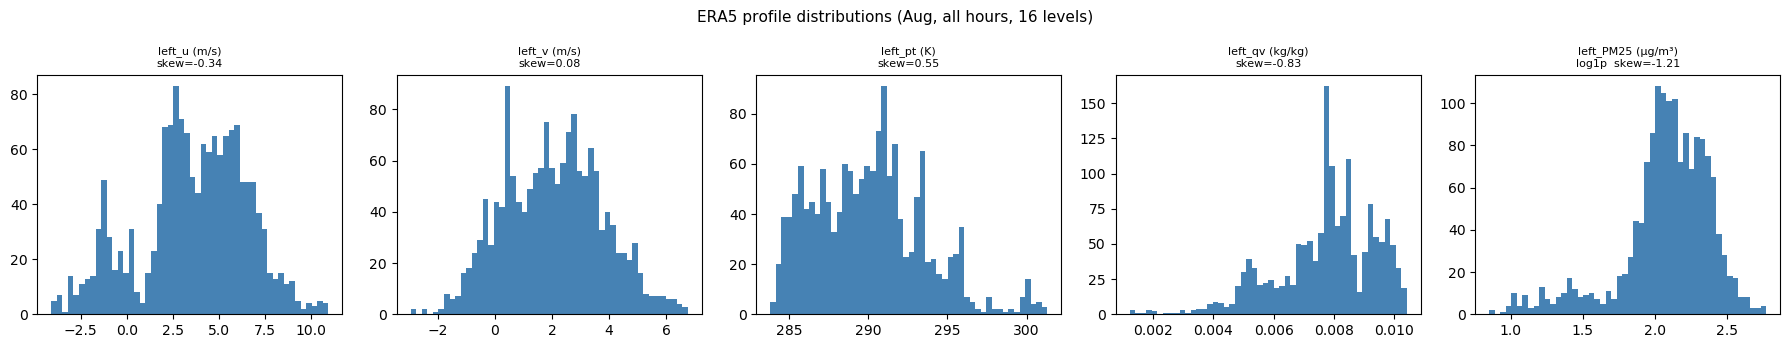

In [10]:
# Distribution of each profile variable
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, var, lbl in zip(axes, DYN_PROFILE_VARS, var_labels):
    vals = profiles_aug[var].ravel()
    if var == 'ls_forcing_left_PM25':
        vals = np.log1p(vals * PM25_SCALE)
        title = f'{lbl}\nlog1p  skew={sp_stats.skew(vals):.2f}'
    else:
        title = f'{lbl}\nskew={sp_stats.skew(vals):.2f}'
    ax.hist(vals, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(title, fontsize=8)
plt.suptitle('ERA5 profile distributions (Aug, all hours, 16 levels)', fontsize=11)
plt.tight_layout(rect=[0,0,1,0.92])
plt.show()

left_u/v/pt/qv: near-Gaussian -> z-score

left_PM25: right-skewed -> log1p -> z-score

### 1.5  Surface Pressure (ch 7/15) and Time Encoding (ch 8–9 / 16–17)

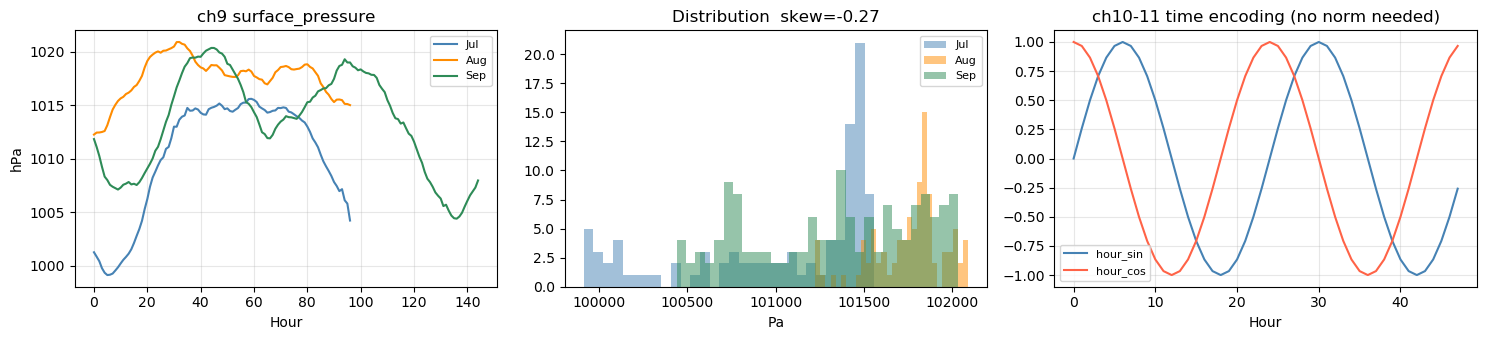

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

# Surface pressure
for sim, col, ep_lbl in zip(SIM_CONFIG, colors_ep, labels_ep):
    p = os.path.join(BASE_DIR, sim, 'INPUT', SIM_CONFIG[sim]['dyn_file'])
    with nc.Dataset(p) as ds:
        th = np.array(ds.variables['time'][:]) / 3600
        sp = np.array(ds.variables['surface_forcing_surface_pressure'][th <= SIM_CONFIG[sim]['sim_hours']])
    axes[0].plot(th[th <= SIM_CONFIG[sim]['sim_hours']], sp/100, color=col, label=ep_lbl, lw=1.5)
    axes[1].hist(sp, bins=30, color=col, alpha=0.5, label=ep_lbl)
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('hPa'); axes[0].set_title('ch9 surface_pressure')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Pa'); axes[1].set_title(f'Distribution  skew={sp_stats.skew(sp):.2f}')
axes[1].legend(fontsize=8)

# Time encoding
h = np.arange(0, 48)
axes[2].plot(h, np.sin(2*np.pi*h/24), label='hour_sin', color='steelblue')
axes[2].plot(h, np.cos(2*np.pi*h/24), label='hour_cos', color='tomato')
axes[2].set_xlabel('Hour'); axes[2].set_title('ch10-11 time encoding (no norm needed)')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 1.6  Temporal history (t vs t−1)

Every physical variable is stacked at the current hour **t** and the previous hour **t−1**,
giving the network one hour of forcing history (18 = 9 × 2 channels). Below: the boundary
PM2.5 profile at consecutive hours, and the distribution of the hour-to-hour change — the
extra information the t−1 block carries. (Leave-one-out retraining in nb 02 shows this
history is mostly useful for the upper levels.)

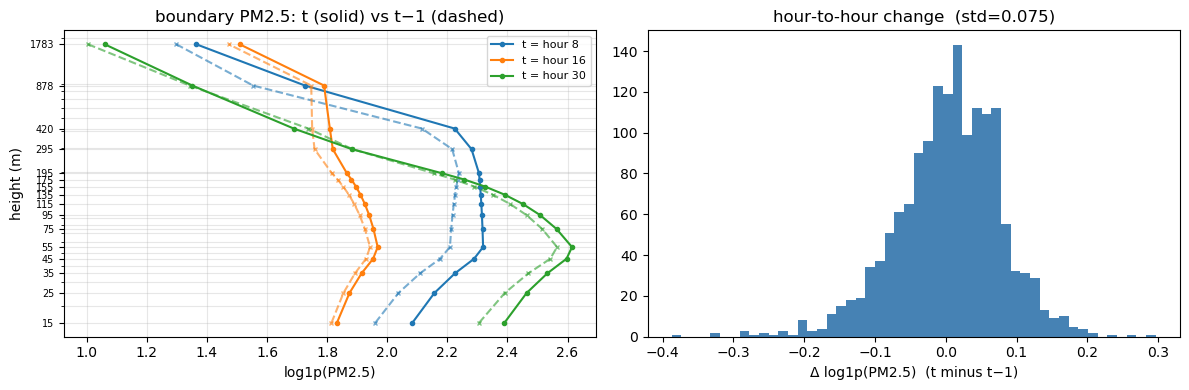

mean |Δ| per hour: 0.057 log-units — non-trivial trend info in t−1


In [12]:
# t vs t-1 illustrated on the boundary PM2.5 inflow profile (log1p space)
pm_prof = np.log1p(profiles_aug['ls_forcing_left_PM25'] * PM25_SCALE)   # (hours, 16 levels)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for h in [8, 16, 30]:
    axes[0].plot(pm_prof[h],   z_dyn, 'o-', ms=3, label=f't = hour {h}')
    axes[0].plot(pm_prof[h-1], z_dyn, 'x--', ms=3, color=axes[0].lines[-1].get_color(), alpha=0.6)
axes[0].set_yscale('log'); axes[0].set_yticks(z_dyn)
axes[0].set_yticklabels([f'{v:.0f}' for v in z_dyn], fontsize=7)
axes[0].set_xlabel('log1p(PM2.5)'); axes[0].set_ylabel('height (m)')
axes[0].set_title('boundary PM2.5: t (solid) vs t−1 (dashed)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, which='both')

dpm = pm_prof[1:] - pm_prof[:-1]     # hour-to-hour change across all levels
axes[1].hist(dpm.ravel(), bins=50, color='steelblue')
axes[1].set_xlabel('Δ log1p(PM2.5)  (t minus t−1)')
axes[1].set_title(f'hour-to-hour change  (std={dpm.std():.3f})')
plt.tight_layout(); plt.show()
print(f'mean |Δ| per hour: {np.abs(dpm).mean():.3f} log-units — non-trivial trend info in t−1')

### 1.6  PM2.5 Output (Target Variable)

In [13]:
pm_per_level = [[] for _ in range(N_Z)]
for f in av_files:
    with nc.Dataset(f) as ds:
        pm = np.array(ds.variables['kc_PM25_xy'][:].filled(np.nan)) * PM25_SCALE  # (T,17,H,W)
    pm = pm[:, 1:]  # skip z0 (PALM_OUT_Z0=1), now shape (T,16,H,W)
    for z in range(N_Z):
        v = pm[:, z].ravel()
        pm_per_level[z].extend(v[~np.isnan(v)][::100].tolist())

with nc.Dataset(av_files[0]) as ds:
    pm_t0_ref = np.array(ds.variables['kc_PM25_xy'][0].filled(np.nan))

print(f'{"z":>3}  {"Height(m)":>10}  {"mean μg/m³":>11}  {"std":>7}  {"skew_raw":>9}  {"skew_log1p":>10}  {"NaN%":>7}')
print('-'*68)
for z in range(N_Z):
    v       = np.array(pm_per_level[z])
    nan_pct = 100 * np.isnan(pm_t0_ref[z + 1]).mean()
    print(f'{z:>3}  {z_levels[z]:>10.0f}  {v.mean():>11.3f}  {v.std():>7.3f}  '
          f'{sp_stats.skew(v):>9.2f}  {sp_stats.skew(np.log1p(v)):>10.2f}  {nan_pct:>6.1f}%')

  z   Height(m)   mean μg/m³      std   skew_raw  skew_log1p     NaN%
--------------------------------------------------------------------
  0          15       13.078   11.042      19.00        1.34    96.2%
  1          25       13.501   10.492      26.62        1.08    85.6%
  2          35       12.549    8.522      44.65        0.95    63.7%
  3          45       11.737    5.994       7.18        0.84    44.1%
  4          55       11.132    5.441      12.70        0.80    30.0%
  5          75       10.181    3.989       1.99        0.66    15.1%
  6          95        9.573    3.286       1.81        0.52     8.2%
  7         115        9.104    2.756       1.49        0.41     2.6%
  8         135        8.705    2.347       1.40        0.34     0.2%


  9         155        8.346    2.029       1.42        0.34     0.0%
 10         175        7.983    1.725       1.49        0.39     0.0%
 11         195        7.693    1.528       1.46        0.42     0.0%
 12         295        6.619    1.239       1.00        0.09     0.0%
 13         420        5.987    1.210       1.08        0.37     0.0%
 14         878        4.624    1.332       0.73        0.23     0.0%
 15        1783        2.502    0.577       0.13       -0.12     0.0%


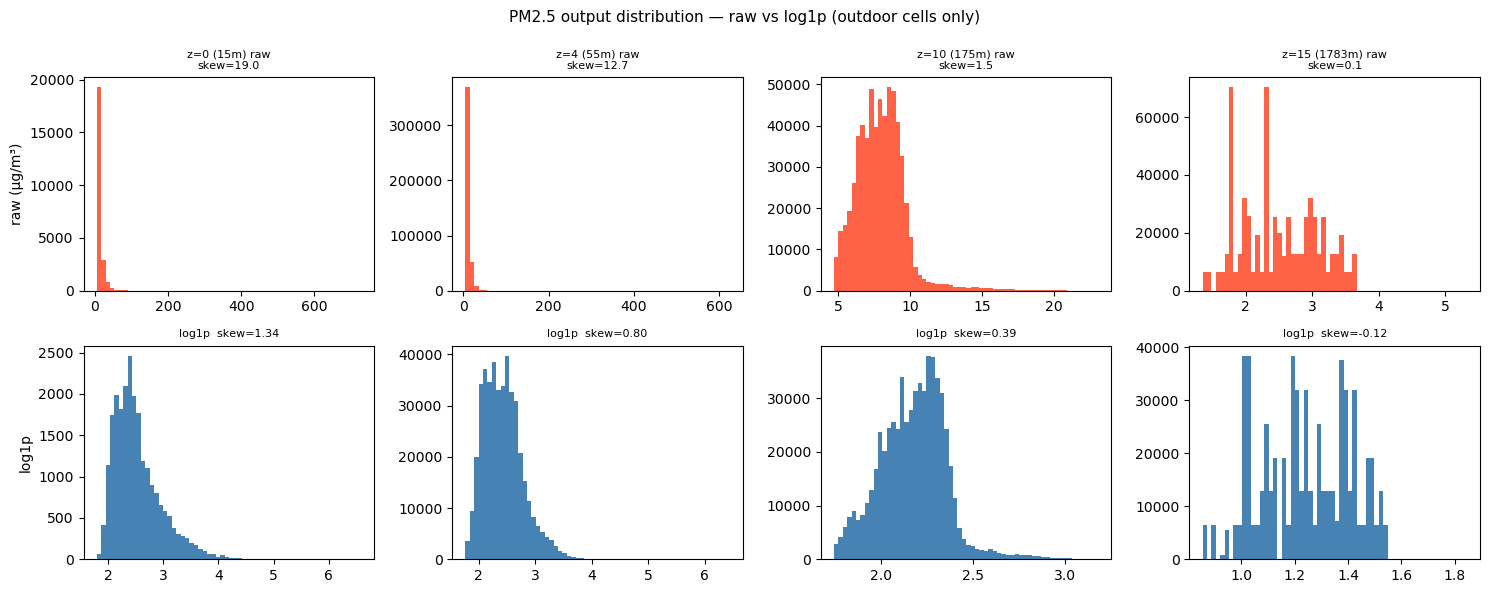

In [14]:
show_z = [0, 4, 10, 15]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for col, z in enumerate(show_z):
    v = np.array(pm_per_level[z])
    axes[0, col].hist(v, bins=60, color='tomato', edgecolor='none')
    axes[0, col].set_title(f'z={z} ({z_levels[z]:.0f}m) raw\nskew={sp_stats.skew(v):.1f}', fontsize=8)
    vl = np.log1p(v)
    axes[1, col].hist(vl, bins=60, color='steelblue', edgecolor='none')
    axes[1, col].set_title(f'log1p  skew={sp_stats.skew(vl):.2f}', fontsize=8)
axes[0,0].set_ylabel('raw (μg/m³)'); axes[1,0].set_ylabel('log1p')
plt.suptitle('PM2.5 output distribution — raw vs log1p (outdoor cells only)', fontsize=11)
plt.tight_layout(rect=[0,0,1,0.94]); plt.show()

### 1.7  Building Mask

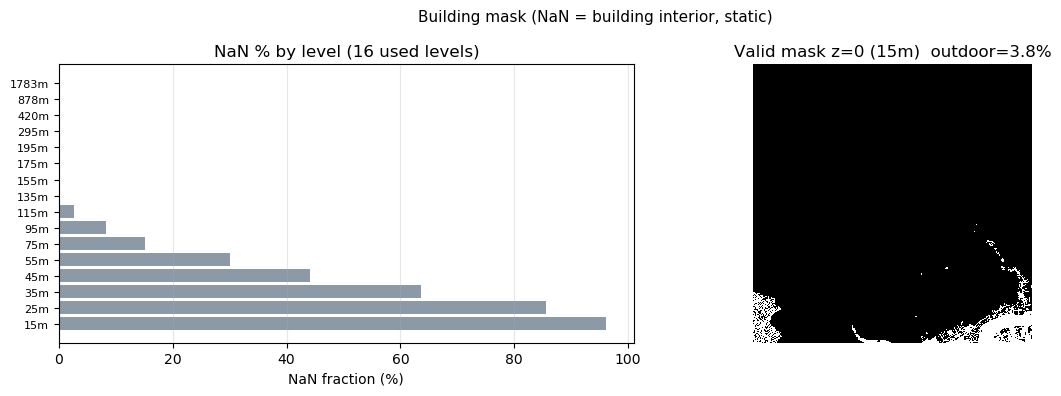

In [15]:
with nc.Dataset(av_files[0]) as ds:
    pm_t0 = np.array(ds.variables['kc_PM25_xy'][0].filled(np.nan))
nan_pct = [100*np.isnan(pm_t0[1+z]).mean() for z in range(N_Z)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(range(N_Z), nan_pct, color='slategray', alpha=0.8)
axes[0].set_yticks(range(N_Z))
axes[0].set_yticklabels([f'{z_levels[z]:.0f}m' for z in range(N_Z)], fontsize=8)
axes[0].set_xlabel('NaN fraction (%)'); axes[0].set_title('NaN % by level (16 used levels)')
axes[0].grid(True, alpha=0.3, axis='x')
axes[1].imshow(~np.isnan(pm_t0[1]), cmap='gray', origin='lower')
axes[1].set_title(f'Valid mask z=0 (15m)  outdoor={100*(~np.isnan(pm_t0[1])).mean():.1f}%')
axes[1].axis('off')
plt.suptitle('Building mask (NaN = building interior, static)', fontsize=11)
plt.tight_layout(rect=[0,0,1,0.93]); plt.show()

---
## Part 2: Preprocessing Summary

### 2.1  Normalisation Decisions

| Channel(s) | Variable | Method | Reason |
|---|---|---|---|
| ch 0, 1 | PM2.5 surface emission (t, t−1) | log1p → z-score | Strongly right-skewed, ~98% zero cells |
| ch 2, 10 | `left_u` | z-score | Near-Gaussian (skew −0.34) |
| ch 3, 11 | `left_v` | z-score | Near-Gaussian (skew 0.08) |
| ch 4, 12 | `left_pt` | z-score | Near-Gaussian (skew 0.55) |
| ch 5, 13 | `left_qv` | z-score | Near-Gaussian (skew −0.83) |
| ch 6, 14 | `left_PM25` (boundary) | log1p → z-score | Right-skewed boundary inflow profile |
| ch 7, 15 | `surface_pressure` | z-score | Near-Gaussian, narrow range (~1007–1021 hPa) |
| ch 8–9, 16–17 | `hour_sin`, `hour_cos` | None | Already in [−1, 1] |
| **y** | PM2.5 output (12 levels) | log1p → z-score (per-level) | Right-skewed; per-level for magnitude across heights |

Each physical variable is stacked at **t and t−1** (one hour of history); leave-one-out
retraining (notebook 02) shows t−1 mainly benefits the **upper levels** (135–195 m).

### 2.2  Train / Test Split and Normalisation Stats

In [16]:
from dataloader import temporal_split

train_ds, _, test_ds = temporal_split(
    val_hours={},
    test_hours={
        'london_cm20190720-23': (72, 96),
        'london_cm20190820-23': (72, 96),
        'london_cm20190904-07': (120, 144),
    },
    roi=(0, 200, 0, 200), normalise=False,
)
print(f'Train: {len(train_ds)} samples  Test: {len(test_ds)} samples')
print('Test = last 24h of each episode (post spin-up), no val set')

train_ds.fit_normalisation()
stats = train_ds.get_stats()

print(f'\nEmission (log1p scale): mean={stats["emission"]["mean"]:.4f}  std={stats["emission"]["std"]:.4f}')
print('\nPM2.5 per-level stats (log1p scale):')
print(f'{"z":>3}  {"height":>9}  {"mean":>8}  {"std":>8}')
print('-'*33)
for z in range(N_Z):
    print(f'{z:>3}  {z_levels[z]:>8.0f}m  {stats["pm25"]["mean"][z]:>8.4f}  {stats["pm25"]["std"][z]:>8.4f}')

Temporal split:  train=264  val=0  test=72
Train: 264 samples  Test: 72 samples
Test = last 24h of each episode (post spin-up), no val set
Fitting normalisation on 264 samples...


  50/264


  100/264


  150/264


  200/264


  250/264


Done.
  emission  mean=6.0204  std=0.7876
  pm25      global mean=1.8265e+00  std=4.0394e-01

Emission (log1p scale): mean=6.0204  std=0.7876

PM2.5 per-level stats (log1p scale):
  z     height      mean       std
---------------------------------
  0        15m    1.8265    0.4039
  1        25m    1.8265    0.4039
  2        35m    1.8265    0.4039
  3        45m    1.8265    0.4039
  4        55m    1.8265    0.4039
  5        75m    1.8265    0.4039
  6        95m    1.8265    0.4039
  7       115m    1.8265    0.4039
  8       135m    1.8265    0.4039
  9       155m    1.8265    0.4039
 10       175m    1.8265    0.4039
 11       195m    1.8265    0.4039
 12       295m    1.8265    0.4039
 13       420m    1.8265    0.4039
 14       878m    1.8265    0.4039
 15      1783m    1.8265    0.4039
